# ASSIGNMENT 4
#NAME: A.S.Tritthik Thilagar
# REG NO: 3122237001057

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outliers managed.
No scaling applied for tree-based model.
Fitting 5 folds for each of 720 candidates, totalling 3600 fits
    param_criterion param_max_depth  mean_test_score  mean_f1_score
704        log_loss              30         0.938462       0.917143
665        log_loss              20         0.938462       0.916359
664        log_loss              20         0.938462       0.916359
378         entropy              10         0.938462       0.916359
376         entropy              10         0.938462       0.916359

--- Grid Search Results (Decision Tree) ---
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy: 0.9384615384615385
Accuracy: 0.94 ± 0.02
Precision: 0.93 ± 0.05
Recall: 0.91 ± 0.03
F1 Score: 0.92 ± 0.03

--- Model Performance on

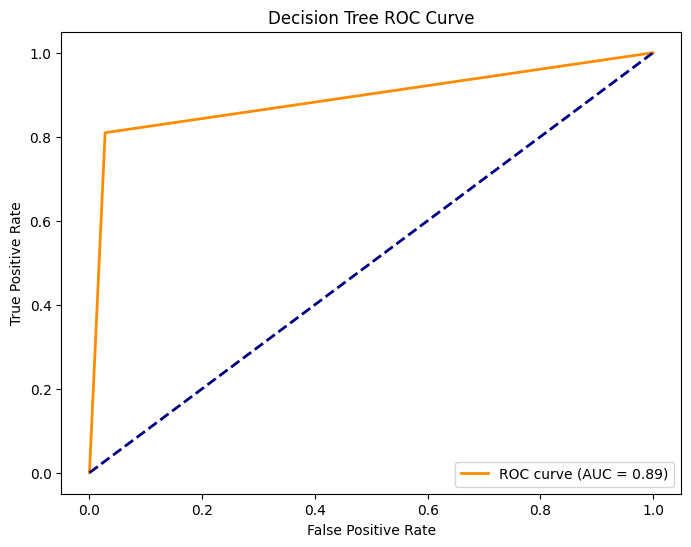

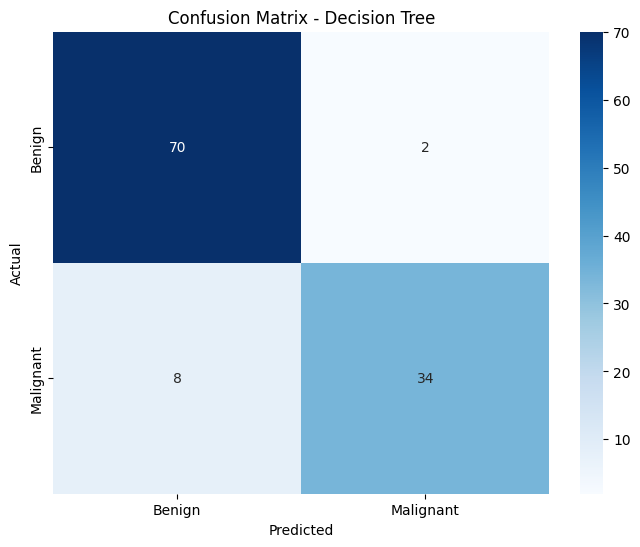

In [ ]:
# 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, confusion_matrix
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from google.colab import drive

# 2. Importing the Dataset
drive.mount('/content/drive')

# Path to Wisconsin Diagnostic dataset
train_path = '/content/drive/MyDrive/Colab Notebooks/EX4/dataset_a4/wdbc.data'

# Dataset has no header, so we assign columns manually
cols = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv(train_path, header=None, names=cols)

# Target encoding: M = 1 (Malignant), B = 0 (Benign)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Features and target
X = df.drop(columns=['ID', 'Diagnosis'])
y = df['Diagnosis']

# Identify numerical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# --- Outlier Management (Capping with IQR method) ---
for col in numerical_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.where(X[col] < lower_bound, lower_bound, X[col])
    X[col] = np.where(X[col] > upper_bound, upper_bound, X[col])
print("Outliers managed.")

# 4. Splitting the Dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

# --- Scaling Logic ---
def choose_scaler(model):
    if isinstance(model, (GaussianNB, LogisticRegression, Ridge, Lasso, SVC, KNeighborsClassifier)):
        return StandardScaler()
    elif isinstance(model, (MultinomialNB, BernoulliNB)):
        return MinMaxScaler()
    elif isinstance(model, (DecisionTreeClassifier, RandomForestClassifier)):
        return None
    else:
        print("NO scaling applied for tree based model")
        return None

def auto_scale_model_data(model, X_train, X_test, X_val, X_train_full, numerical_cols):
    scaler = choose_scaler(model)

    if scaler is None:
        print("No scaling applied for tree-based model.")
        return X_train.copy(), X_test.copy(), X_val.copy(), X_train_full.copy()

    print(f"Applying {scaler.__class__.__name__} for model {model.__class__.__name__}")

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    X_val_scaled = X_val.copy()
    X_train_full_scaled = X_train_full.copy()

    X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
    X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
    X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
    X_train_full_scaled[numerical_cols] = scaler.transform(X_train_full[numerical_cols])

    return X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled

# 5. MODEL BUILDING - DECISION TREE with Grid Search
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Base model
model_dt = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=model_dt,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Scale data (same as before)
X_train_scaled, X_test_scaled, X_val_scaled, X_train_full_scaled = auto_scale_model_data(
    model_dt, X_train, X_test, X_val, X_train_full, numerical_cols
)

# Fit GridSearch
grid_search.fit(X_train_full_scaled, y_train_full)

# Results of all parameter combinations
cv_results = pd.DataFrame(grid_search.cv_results_)

# Sort by mean test score
all_results = cv_results[[
    "param_criterion",
    "param_max_depth",
    "mean_test_score"
]].copy()

# Compute F1 score for each parameter combination
f1_scores = []
for i in range(len(cv_results)):
    params = cv_results.iloc[i].params
    dt_temp = DecisionTreeClassifier(**params, random_state=42)
    f1 = cross_val_score(dt_temp, X_train_full_scaled, y_train_full, cv=cv, scoring='f1').mean()
    f1_scores.append(f1)

all_results["mean_f1_score"] = f1_scores

# Sort by accuracy
all_results = all_results.sort_values(by="mean_test_score", ascending=False)

# Keep top 5 (or top 10)
top_results = all_results.head(5)
print(top_results)

# Best params and score
print("\n--- Grid Search Results (Decision Tree) ---")
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Get best model
best_dt = grid_search.best_estimator_

# Evaluate with additional metrics using CV
cv_accuracy = cross_val_score(best_dt, X_train_full_scaled, y_train_full, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(best_dt, X_train_full_scaled, y_train_full, cv=cv, scoring='precision')
cv_recall = cross_val_score(best_dt, X_train_full_scaled, y_train_full, cv=cv, scoring='recall')
cv_f1 = cross_val_score(best_dt, X_train_full_scaled, y_train_full, cv=cv, scoring='f1')

print(f"Accuracy: {cv_accuracy.mean():.2f} ± {cv_accuracy.std():.2f}")
print(f"Precision: {cv_precision.mean():.2f} ± {cv_precision.std():.2f}")
print(f"Recall: {cv_recall.mean():.2f} ± {cv_recall.std():.2f}")
print(f"F1 Score: {cv_f1.mean():.2f} ± {cv_f1.std():.2f}")

# Final fit on best model
best_dt.fit(X_train_full_scaled, y_train_full)

# Predictions
y_pred = best_dt.predict(X_test_scaled)
y_pred_proba = best_dt.predict_proba(X_test_scaled)[:, 1]


# 6. PERFORMANCE EVALUATION
print("\n--- Model Performance on Test Set (Decision Tree) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()


ADABOOST


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Top 5 Results (sorted by F1):
    param_n_estimators  param_learning_rate  mean_test_accuracy  mean_test_f1
0                  50                 0.01             0.92967       0.90629
1                 100                 0.01             0.92967       0.90629
2                 200                 0.01             0.92967       0.90629
3                  50                 0.10             0.92967       0.90629
4                 100                 0.10             0.92967       0.90629

Best Params (AdaBoost): {'learning_rate': 0.01, 'n_estimators': 50}

--- AdaBoost Performance on Test Set ---
Accuracy: 0.90
Precision: 0.88
Recall: 0.86
F1 Score: 0.87

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92        72
           1       0.88      0.86      0.87        42

    accuracy                           0.90       114
   macro avg       0.90      0.8

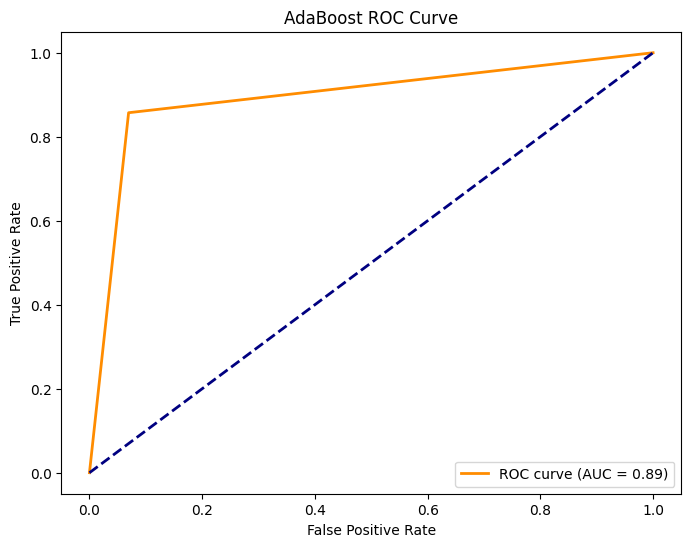

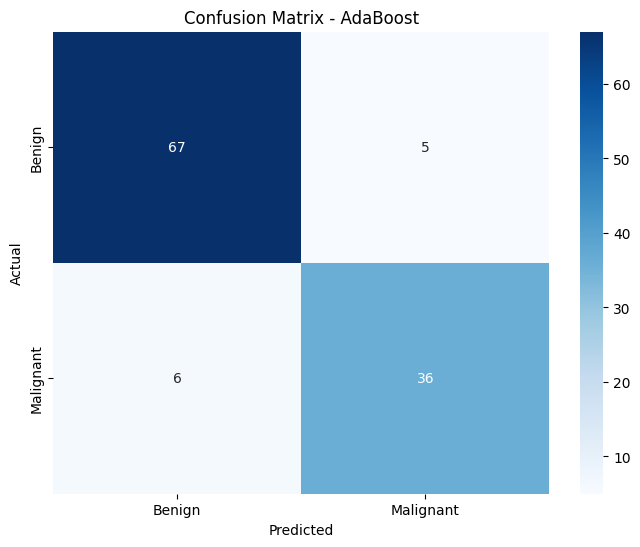

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_curve, auc, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Base decision tree
base_tree = DecisionTreeClassifier(random_state=42)

# AdaBoost setup
model_ab = AdaBoostClassifier(estimator=base_tree, random_state=42)

# Parameter grid
param_grid_ab = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
}

# Grid search with both accuracy & f1
grid_ab = GridSearchCV(
    model_ab,
    param_grid_ab,
    cv=5,
    scoring={'accuracy': 'accuracy', 'f1': 'f1'},
    refit='f1',  # pick best params by F1
    n_jobs=-1,
    verbose=1
)

# Fit
grid_ab.fit(X_train_full, y_train_full)

# Results of all parameter combinations
cv_results = pd.DataFrame(grid_ab.cv_results_)

all_results_ab = cv_results[[
    "param_n_estimators",
    "param_learning_rate",
    "mean_test_accuracy",
    "mean_test_f1"
]].copy()

# Show top configs sorted by F1
top_ab = all_results_ab.sort_values(by="mean_test_f1", ascending=False).head(5)
print("\nTop 5 Results (sorted by F1):\n", top_ab)

print("\nBest Params (AdaBoost):", grid_ab.best_params_)
best_ab = grid_ab.best_estimator_

# Predictions
y_pred = best_ab.predict(X_test)
y_pred_proba = best_ab.predict_proba(X_test)[:, 1]

# --- PERFORMANCE EVALUATION ---
print("\n--- AdaBoost Performance on Test Set ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AdaBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost')
plt.show()


GRADIENT BOOSTING

Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Top Parameter Combinations ---
    param_n_estimators  param_learning_rate  param_max_depth  \
20                 300                  0.2                3   
19                 200                  0.2                3   
11                 300                  0.1                3   
18                 100                  0.2                3   
9                  100                  0.1                3   

    mean_test_accuracy  mean_test_f1  
20            0.958242      0.944482  
19            0.956044      0.942046  
11            0.956044      0.940641  
18            0.953846      0.938690  
9             0.953846      0.938236  

Best Params (GradientBoosting): {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}

--- Gradient Boosting Performance ---
Accuracy: 0.96
Precision: 1.00
Recall: 0.90
F1 Score: 0.95

Classification Report:
               precision    recall  f1-score   support

           0

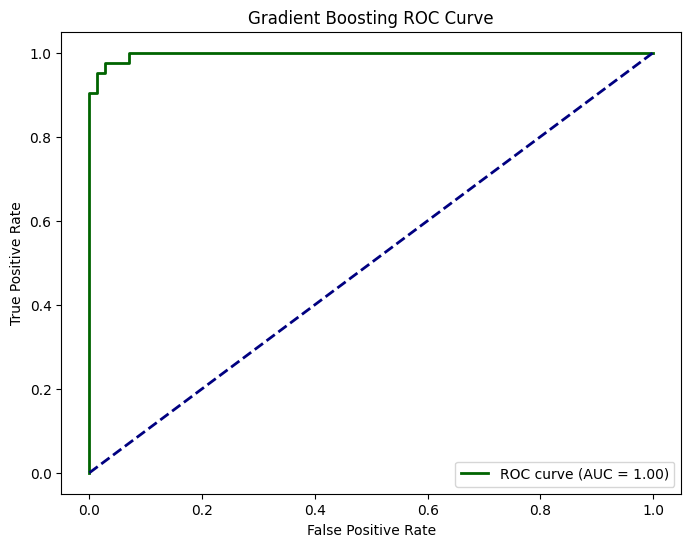

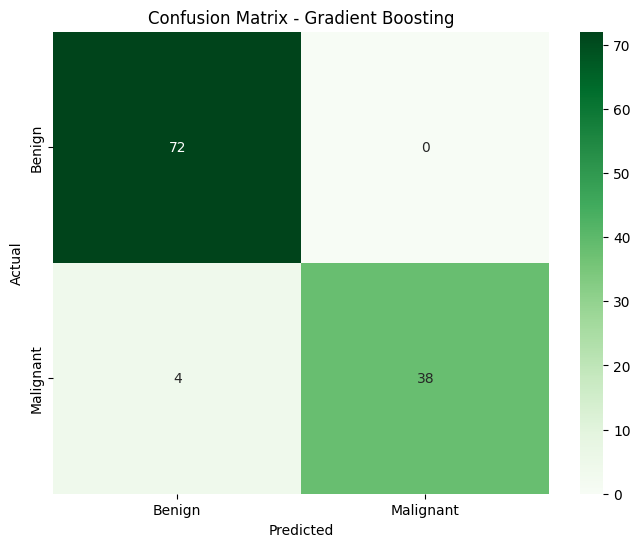

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gradient Boosting model
model_gb = GradientBoostingClassifier(random_state=42)

# Parameter grid
param_grid_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]  # still valid because GradientBoostingClassifier accepts it
}

# Grid search with multiple scoring
grid_gb = GridSearchCV(
    model_gb,
    param_grid_gb,
    cv=5,
    scoring={'accuracy': 'accuracy', 'f1': 'f1'},
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_full, y_train_full)

# Results
cv_results_gb = pd.DataFrame(grid_gb.cv_results_)
all_results_gb = cv_results_gb[
    ["param_n_estimators", "param_learning_rate", "param_max_depth", "mean_test_accuracy", "mean_test_f1"]
]

print("\n--- Top Parameter Combinations ---")
print(all_results_gb.sort_values(by="mean_test_f1", ascending=False).head())

# Best model
print("\nBest Params (GradientBoosting):", grid_gb.best_params_)
best_gb = grid_gb.best_estimator_

# Predictions
y_pred = best_gb.predict(X_test)
y_pred_proba = best_gb.predict_proba(X_test)[:, 1]

# --- PERFORMANCE ---
print("\n--- Gradient Boosting Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()


XG BOOST

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:09:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Top Results:
     param_n_estimators  param_learning_rate  param_max_depth  param_gamma  \
26                 300                  0.2                7            0   
25                 200                  0.2                7            0   
17                 300                  0.1                7            0   
14                 300                  0.1                5            0   
15                 100                  0.1                7            0   

    mean_test_accuracy  mean_test_f1  
26            0.964835      0.953270  
25            0.964835      0.953270  
17            0.964835      0.952766  
14            0.964835      0.952766  
15            0.962637      0.951118  

Best Params (XGBoost): {'gamma': 0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}

--- XGBoost Performance ---
Accuracy: 0.96
Precision: 1.00
Recall: 0.90
F1 Score: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       0.95 

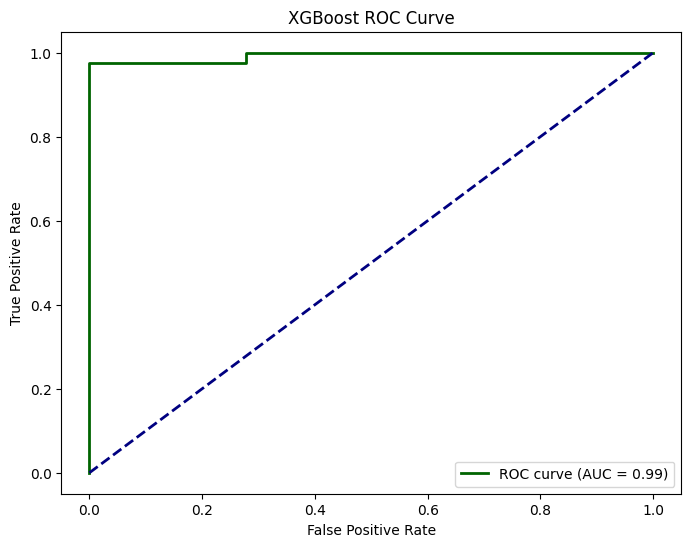

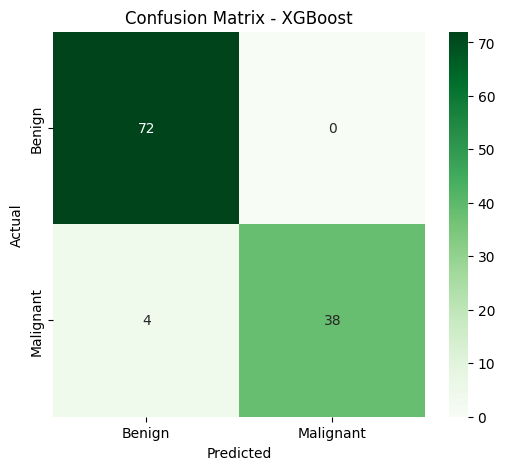

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Model & Grid ---
model_xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "gamma": [0, 1, 5]
}

# --- Grid Search with both Accuracy & F1 ---
grid_xgb = GridSearchCV(
    model_xgb,
    param_grid_xgb,
    cv=5,
    scoring={'accuracy': 'accuracy', 'f1': 'f1'},
    refit='f1',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_full, y_train_full)

# --- Results ---
cv_results_xgb = pd.DataFrame(grid_xgb.cv_results_)
all_results_xgb = cv_results_xgb[
    ["param_n_estimators", "param_learning_rate", "param_max_depth", "param_gamma",
     "mean_test_accuracy", "mean_test_f1"]
]

print("\nTop Results:\n", all_results_xgb.sort_values(by="mean_test_f1", ascending=False).head(5))

print("\nBest Params (XGBoost):", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_

# --- Predictions ---
y_pred = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

# --- Performance ---
print("\n--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()


RANDOM FOREST CLASSIFIER

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Top 5 Random Forest Configurations:
     param_n_estimators param_max_depth param_criterion  mean_test_accuracy  \
16                 200              10         entropy            0.964835   
19                 200              20         entropy            0.964835   
22                 200              30         entropy            0.964835   
13                 200            None         entropy            0.964835   
23                 500              30         entropy            0.962637   

    mean_test_f1  
16      0.952111  
19      0.952111  
22      0.952111  
13      0.952111  
23      0.949126  

Best Params (RandomForest): {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 200}

--- Random Forest Performance ---
Accuracy: 0.97
Precision: 1.00
Recall: 0.93
F1 Score: 0.96

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      

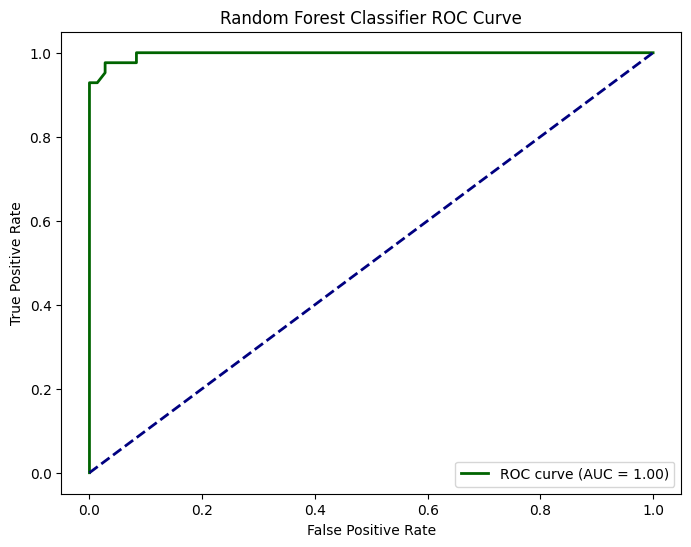

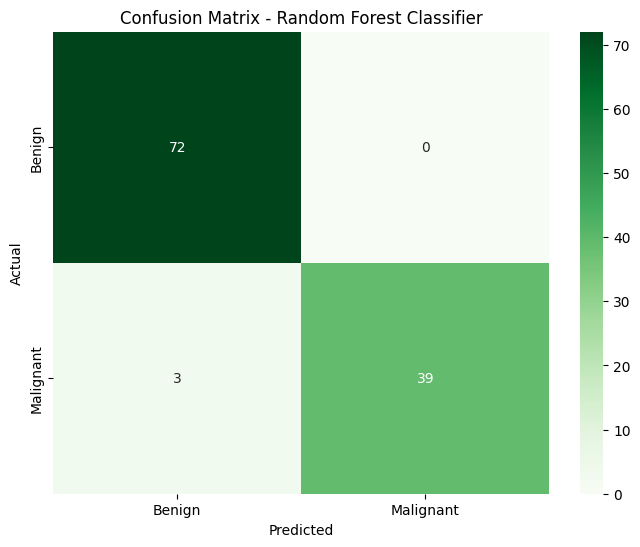

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, roc_curve, auc, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- MODEL ---
model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# --- Hyperparameter Grid ---
param_grid_rf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "criterion": ["gini", "entropy"]
}

# --- Grid Search ---
grid_rf = GridSearchCV(
    model_rf, param_grid_rf,
    cv=5,
    scoring={'accuracy': 'accuracy', 'f1': 'f1'},
    refit='f1',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train_full, y_train_full)

# --- Results ---
cv_results_rf = pd.DataFrame(grid_rf.cv_results_)
all_results_rf = cv_results_rf[[
    "param_n_estimators", "param_max_depth", "param_criterion",
    "mean_test_accuracy", "mean_test_f1"
]]

# Sort by F1 score (since refit='f1')
top_rf = all_results_rf.sort_values(by="mean_test_f1", ascending=False).head(5)
print("\nTop 5 Random Forest Configurations:\n", top_rf)

print("\nBest Params (RandomForest):", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# --- Predictions ---
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# --- Performance Metrics ---
print("\n--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Classifier ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()


# STACKED MODELS



=== SVM+NB+DT → LogisticRegression ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[71  1]
 [ 2 40]]

=== SVM+NB+DT → RandomForest ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[71  1]
 [ 1 41]]

=== SVM+DT+KNN → LogisticRegression ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98   

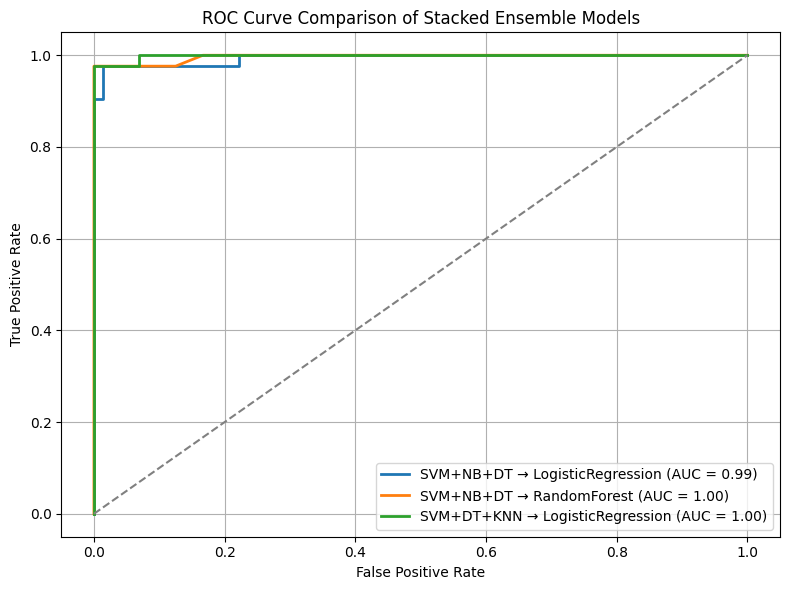


Final Comparison Table:

                             Model  Accuracy  F1 Score
0   SVM+NB+DT → LogisticRegression  0.973684  0.963855
1         SVM+NB+DT → RandomForest  0.982456  0.976190
2  SVM+DT+KNN → LogisticRegression  0.982456  0.975610


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_curve, auc
)

# --------------------------
# DEFINE STACKED MODELS
# --------------------------

# 1) SVM, Naive Bayes, Decision Tree → Logistic Regression
model1 = StackingClassifier(
    estimators=[
        ("svm", make_pipeline(StandardScaler(), SVC(probability=True))),
        ("nb", GaussianNB()),
        ("dt", DecisionTreeClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# 2) SVM, Naive Bayes, Decision Tree → Random Forest
model2 = StackingClassifier(
    estimators=[
        ("svm", make_pipeline(StandardScaler(), SVC(probability=True))),
        ("nb", GaussianNB()),
        ("dt", DecisionTreeClassifier(random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=42),
    cv=5,
    n_jobs=-1
)

# 3) SVM, Decision Tree, KNN → Logistic Regression
model3 = StackingClassifier(
    estimators=[
        ("svm", make_pipeline(StandardScaler(), SVC(probability=True))),
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("knn", KNeighborsClassifier())
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# --------------------------
# TRAIN & EVALUATE MODELS
# --------------------------

models = {
    "SVM+NB+DT → LogisticRegression": model1,
    "SVM+NB+DT → RandomForest": model2,
    "SVM+DT+KNN → LogisticRegression": model3
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]   # for ROC

    # Accuracy and F1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# --------------------------
# ROC PLOT
# --------------------------
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Stacked Ensemble Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# --------------------------
# RESULTS TABLE
# --------------------------
results_df = pd.DataFrame(results)
print("\nFinal Comparison Table:\n")
print(results_df)
